# **Import**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import joblib
from sklearn.tree import plot_tree
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# **Leitura do dataset**

In [ ]:
#Lendo dataset
dfSpyware = pd.read_csv("dataset_spyware_float32.csv")

# **Separação e padronização dos dados**

In [ ]:
#Usando Label Encoder
X = dfSpyware.drop(columns=['Category'])
Y = dfSpyware['Category']
le = LabelEncoder()
Y = le.fit_transform(Y)
print(dict(zip(le.classes_, range(len(le.classes_)))))

In [ ]:
#Padronizando os dados
scaler = StandardScaler()
X_standardized_array = scaler.fit_transform(X)
X_standardized = pd.DataFrame(
    X_standardized_array,
    columns=X.columns
)

In [ ]:
#Separando os dados de teste e treinamento
X_train, X_test, Y_train, Y_test = train_test_split(X_standardized,Y,test_size=0.2,random_state=42,stratify=Y)

# **Random Forest**

In [ ]:
#Criando o modelo
modelRandomForest = RandomForestClassifier(
    random_state=42,
    n_estimators=10,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=10
)
modelRandomForest.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=10, min_samples_split=10,
                       n_estimators=10, random_state=42)

In [ ]:
#Valor de Acurácia e F1-Score
y_pred = modelRandomForest.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

Acurácia: 0.6426
F1-Score (weighted): 0.6399


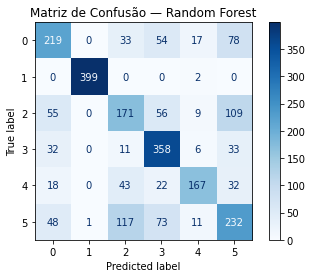

In [ ]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão — Random Forest")
plt.savefig(
    "matriz_confusao_random_forest.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
joblib.dump(modelRandomForest, 'modelo_random_forest.pkl')

['modelo_random_forest.pkl']

In [ ]:
y_predRF = modelRandomForest.predict(X_test)
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_predRF,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.58871   0.54613   0.56662       401
           1    0.99750   0.99501   0.99625       401
           2    0.45600   0.42750   0.44129       400
           3    0.63588   0.81364   0.71386       440
           4    0.78774   0.59220   0.67611       282
           5    0.47934   0.48133   0.48033       482

    accuracy                        0.64256      2406
   macro avg    0.65753   0.64263   0.64575      2406
weighted avg    0.64482   0.64256   0.63986      2406



K-fold

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(modelRandomForest, X, Y, cv=cv, scoring='f1_weighted')
print("CV F1-scores por fold:", scores)
print("F1-Score médio (CV):", np.mean(scores))
print("F1-Score Desvio (CV):", np.std(scores))

CV F1-scores por fold: [0.6339834  0.66250643 0.644418   0.65739755 0.64287702 0.65802391
 0.65763878 0.65555519 0.64979218 0.63347253]
F1-Score médio (CV): 0.6495664982529017
F1-Score Desvio (CV): 0.009871560872088509


In [ ]:
acc_scores = cross_val_score(modelRandomForest, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia Desvio padrão (CV):", np.std(acc_scores))

CV Acurácia por fold: [0.63757273 0.66500416 0.64505403 0.66001663 0.64256027 0.66167914
 0.65806988 0.66139767 0.65058236 0.63727121]
Acurácia média (CV): 0.6519208080741021
Acurácia Desvio padrão (CV): 0.010082682458514968


# **Naive Bayes**




In [ ]:
modelNB = GaussianNB()
modelNB.fit(X_train, Y_train)
y_predNB = modelNB.predict(X_test)

In [ ]:
acc = accuracy_score(Y_test, y_predNB)
print(f"Accuracy (Naive Bayes): {acc:.4f}")

f1 = f1_score(Y_test, y_predNB, average='weighted')
print(f"F1-Score (weighted, Naive Bayes): {f1:.4f}")

Accuracy (Naive Bayes): 0.4393
F1-Score (weighted, Naive Bayes): 0.3637


In [ ]:
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_predNB,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.57576   0.04738   0.08756       401
           1    0.99244   0.98254   0.98747       401
           2    0.41497   0.15250   0.22303       400
           3    0.29286   0.93182   0.44565       440
           4    0.39303   0.56028   0.46199       282
           5    0.55556   0.03112   0.05894       482

    accuracy                        0.43932      2406
   macro avg    0.53744   0.45094   0.37744      2406
weighted avg    0.54127   0.43932   0.36371      2406



In [ ]:
joblib.dump(modelNB, 'modelo_NaiveBayes.pkl')

['modelo_NaiveBayes.pkl']

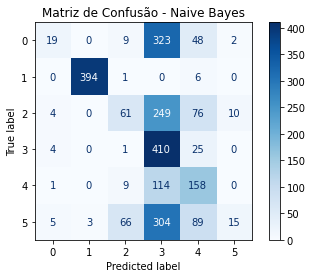

In [ ]:
cm = confusion_matrix(Y_test, y_predNB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Naive Bayes")
plt.savefig("matriz_confusao_naiveBayes.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
f1_scores = cross_val_score(modelNB, X, Y, cv=cv, scoring='f1_weighted')
print("CV F1-scores por fold:", f1_scores)
print("F1-Score médio (CV):", np.mean(f1_scores))
print("F1-Score desvio (CV):", np.std(f1_scores))

CV F1-scores por fold: [0.41858186 0.40621369 0.40939821 0.38880228 0.42125437 0.39178084
 0.39837581 0.40024786 0.3946332  0.40829203]
F1-Score médio (CV): 0.4037580145756551
F1-Score desvio (CV): 0.01037278531940832


In [ ]:
acc_scores = cross_val_score(modelNB, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia desvio (CV):", np.std(acc_scores))

CV Acurácia por fold: [0.47049044 0.45386534 0.45885287 0.44472153 0.46633416 0.45054032
 0.45923461 0.45424293 0.44509151 0.45590682]
Acurácia média (CV): 0.45592805285731863
Acurácia desvio (CV): 0.007867512268291058


# **MLP**

In [ ]:
modelMLP = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=20,
    batch_size=64,
    random_state=42,
    verbose=True
)

In [ ]:
modelMLP.fit(X_train, Y_train)
y_pred = modelMLP.predict(X_test)

Iteration 1, loss = 1.26484042
Iteration 2, loss = 1.12202528
Iteration 3, loss = 1.09814681
Iteration 4, loss = 1.08415466
Iteration 5, loss = 1.07552558
Iteration 6, loss = 1.05630591
Iteration 7, loss = 1.05011240
Iteration 8, loss = 1.04164333
Iteration 9, loss = 1.02916156
Iteration 10, loss = 1.02097633
Iteration 11, loss = 1.01366658
Iteration 12, loss = 1.00517716
Iteration 13, loss = 1.00092153
Iteration 14, loss = 0.99452763
Iteration 15, loss = 0.98896724
Iteration 16, loss = 0.98428415
Iteration 17, loss = 0.97155759
Iteration 18, loss = 0.96939298
Iteration 19, loss = 0.96109759
Iteration 20, loss = 0.95886693


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


In [ ]:
acc = accuracy_score(Y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

Acurácia: 0.5781
F1-Score (weighted): 0.5766


In [ ]:
joblib.dump(modelMLP, 'modelMLP1.pkl')

['modelMLP1.pkl']

In [ ]:
y_predMLP = modelMLP.predict(X_test)
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_predMLP,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.44492   0.51372   0.47685       401
           1    1.00000   1.00000   1.00000       401
           2    0.46441   0.34250   0.39424       400
           3    0.55354   0.62273   0.58610       440
           4    0.66102   0.55319   0.60232       282
           5    0.42054   0.45021   0.43487       482

    accuracy                        0.57814      2406
   macro avg    0.59074   0.58039   0.58240      2406
weighted avg    0.58098   0.57814   0.57658      2406



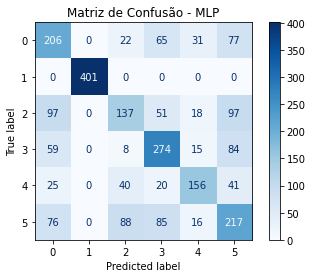

In [ ]:
cm = confusion_matrix(Y_test, y_predMLP)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelMLP.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - MLP")
plt.savefig("matriz_confusaoMLP.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(modelMLP, X, Y, cv=cv, scoring='f1_weighted')
print("F1-scores por fold:", scores)
print("F1-Score médio (CV):", np.mean(scores))
print("F1-Score Desvio (CV):", np.std(scores))

Iteration 1, loss = 13.24704707
Iteration 2, loss = 7.48786651
Iteration 3, loss = 7.92673778
Iteration 4, loss = 6.05282881
Iteration 5, loss = 6.15214459
Iteration 6, loss = 5.17579704
Iteration 7, loss = 4.85977662
Iteration 8, loss = 4.86106019
Iteration 9, loss = 3.86091722
Iteration 10, loss = 2.88735034
Iteration 11, loss = 2.41726998
Iteration 12, loss = 2.84341145
Iteration 13, loss = 2.55203786
Iteration 14, loss = 3.08237474
Iteration 15, loss = 2.23790201
Iteration 16, loss = 1.93946839
Iteration 17, loss = 1.61992474
Iteration 18, loss = 1.56033072
Iteration 19, loss = 1.50270105
Iteration 20, loss = 1.50670170
Iteration 1, loss = 10.08163528


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 4.80164834
Iteration 3, loss = 4.10904663
Iteration 4, loss = 3.38431675
Iteration 5, loss = 2.97594003
Iteration 6, loss = 1.94421950
Iteration 7, loss = 1.78910175
Iteration 8, loss = 1.77485395
Iteration 9, loss = 1.76902907
Iteration 10, loss = 1.76372615
Iteration 11, loss = 1.76106849
Iteration 12, loss = 1.76683837
Iteration 13, loss = 1.76217224
Iteration 14, loss = 1.76556617
Iteration 15, loss = 1.76186706
Iteration 16, loss = 1.76089230
Iteration 17, loss = 1.76172318
Iteration 18, loss = 1.76178253
Iteration 19, loss = 1.75980700
Iteration 20, loss = 1.76056854
Iteration 1, loss = 12.21915406


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 8.59914658
Iteration 3, loss = 5.72496815
Iteration 4, loss = 5.69808660
Iteration 5, loss = 4.60760890
Iteration 6, loss = 4.32173189
Iteration 7, loss = 3.78530032
Iteration 8, loss = 1.86888152
Iteration 9, loss = 2.32938848
Iteration 10, loss = 1.71741082
Iteration 11, loss = 1.83419133
Iteration 12, loss = 1.77915233
Iteration 13, loss = 1.75623777
Iteration 14, loss = 1.91891838
Iteration 15, loss = 1.71094759
Iteration 16, loss = 1.62959588
Iteration 17, loss = 1.83151398
Iteration 18, loss = 1.75123040
Iteration 19, loss = 1.70053386
Iteration 20, loss = 1.59404025
Iteration 1, loss = 11.10038249


...

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 14.17058244
Iteration 2, loss = 8.02471897
Iteration 3, loss = 5.97956710
Iteration 4, loss = 5.76504894
Iteration 5, loss = 4.67079632
Iteration 6, loss = 5.30230221
Iteration 7, loss = 4.54297444
Iteration 8, loss = 4.31230474
Iteration 9, loss = 4.37358495
Iteration 10, loss = 3.30432799
Iteration 11, loss = 3.69837004
Iteration 12, loss = 3.12330371
Iteration 13, loss = 2.82247119
Iteration 14, loss = 3.13602560
Iteration 15, loss = 2.49285090
Iteration 16, loss = 2.36375485
Iteration 17, loss = 2.24544096
Iteration 18, loss = 1.90783887
Iteration 19, loss = 1.63474239
Iteration 20, loss = 1.51623274
Iteration 1, loss = 13.79250336


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 7.86944909
Iteration 3, loss = 6.89860875
Iteration 4, loss = 5.71403432
Iteration 5, loss = 5.22269436
Iteration 6, loss = 4.33381611
Iteration 7, loss = 3.69182817
Iteration 8, loss = 2.58108423
Iteration 9, loss = 2.39510941
Iteration 10, loss = 2.97949701
Iteration 11, loss = 2.24323945
Iteration 12, loss = 2.09269360
Iteration 13, loss = 1.82360465
Iteration 14, loss = 1.86434747
Iteration 15, loss = 1.69132692
Iteration 16, loss = 1.94610447
Iteration 17, loss = 1.69164326
Iteration 18, loss = 1.71624717
Iteration 19, loss = 1.55371800
Iteration 20, loss = 1.83011210
F1-scores por fold: [0.31844484 0.08359318 0.32763869 0.08657427 0.25668229 0.07696139
 0.08524649 0.08311678 0.27263959 0.27823732]
F1-Score médio (CV): 0.1869134844032331
F1-Score Desvio (CV): 0.10564242405528128


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
acc_scores = cross_val_score(modelMLP, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia desvio (CV):", np.std(acc_scores))

Iteration 1, loss = 13.24704707
Iteration 2, loss = 7.48786651
Iteration 3, loss = 7.92673778
Iteration 4, loss = 6.05282881
Iteration 5, loss = 6.15214459
Iteration 6, loss = 5.17579704
Iteration 7, loss = 4.85977662
Iteration 8, loss = 4.86106019
Iteration 9, loss = 3.86091722
Iteration 10, loss = 2.88735034
Iteration 11, loss = 2.41726998
Iteration 12, loss = 2.84341145
Iteration 13, loss = 2.55203786
Iteration 14, loss = 3.08237474
Iteration 15, loss = 2.23790201
Iteration 16, loss = 1.93946839
Iteration 17, loss = 1.61992474
Iteration 18, loss = 1.56033072
Iteration 19, loss = 1.50270105
Iteration 20, loss = 1.50670170
Iteration 1, loss = 10.08163528


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 4.80164834
Iteration 3, loss = 4.10904663
Iteration 4, loss = 3.38431675
Iteration 5, loss = 2.97594003
Iteration 6, loss = 1.94421950
Iteration 7, loss = 1.78910175
Iteration 8, loss = 1.77485395
Iteration 9, loss = 1.76902907
Iteration 10, loss = 1.76372615
Iteration 11, loss = 1.76106849
Iteration 12, loss = 1.76683837
Iteration 13, loss = 1.76217224
Iteration 14, loss = 1.76556617
Iteration 15, loss = 1.76186706
Iteration 16, loss = 1.76089230
Iteration 17, loss = 1.76172318
Iteration 18, loss = 1.76178253
Iteration 19, loss = 1.75980700
Iteration 20, loss = 1.76056854
Iteration 1, loss = 12.21915406


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 8.59914658
Iteration 3, loss = 5.72496815
Iteration 4, loss = 5.69808660
Iteration 5, loss = 4.60760890
Iteration 6, loss = 4.32173189
Iteration 7, loss = 3.78530032
Iteration 8, loss = 1.86888152
Iteration 9, loss = 2.32938848
Iteration 10, loss = 1.71741082
Iteration 11, loss = 1.83419133
Iteration 12, loss = 1.77915233
Iteration 13, loss = 1.75623777
Iteration 14, loss = 1.91891838
Iteration 15, loss = 1.71094759
Iteration 16, loss = 1.62959588
Iteration 17, loss = 1.83151398
Iteration 18, loss = 1.75123040
Iteration 19, loss = 1.70053386
Iteration 20, loss = 1.59404025


...

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 8.02471897
Iteration 3, loss = 5.97956710
Iteration 4, loss = 5.76504894
Iteration 5, loss = 4.67079632
Iteration 6, loss = 5.30230221
Iteration 7, loss = 4.54297444
Iteration 8, loss = 4.31230474
Iteration 9, loss = 4.37358495
Iteration 10, loss = 3.30432799
Iteration 11, loss = 3.69837004
Iteration 12, loss = 3.12330371
Iteration 13, loss = 2.82247119
Iteration 14, loss = 3.13602560
Iteration 15, loss = 2.49285090
Iteration 16, loss = 2.36375485
Iteration 17, loss = 2.24544096
Iteration 18, loss = 1.90783887
Iteration 19, loss = 1.63474239
Iteration 20, loss = 1.51623274
Iteration 1, loss = 13.79250336


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 7.86944909
Iteration 3, loss = 6.89860875
Iteration 4, loss = 5.71403432
Iteration 5, loss = 5.22269436
Iteration 6, loss = 4.33381611
Iteration 7, loss = 3.69182817
Iteration 8, loss = 2.58108423
Iteration 9, loss = 2.39510941
Iteration 10, loss = 2.97949701
Iteration 11, loss = 2.24323945
Iteration 12, loss = 2.09269360
Iteration 13, loss = 1.82360465
Iteration 14, loss = 1.86434747
Iteration 15, loss = 1.69132692
Iteration 16, loss = 1.94610447
Iteration 17, loss = 1.69164326
Iteration 18, loss = 1.71624717
Iteration 19, loss = 1.55371800
Iteration 20, loss = 1.83011210
CV Acurácia por fold: [0.41064007 0.20864505 0.37988362 0.20947631 0.35660848 0.20532003
 0.20965058 0.20715474 0.32445923 0.36189684]
Acurácia média (CV): 0.2873734963755338
Acurácia desvio (CV): 0.08182306795381399


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


# **Melhor modelo selecionado para o SHAP**



PermutationExplainer explainer: 2407it [01:58, 18.86it/s]                          


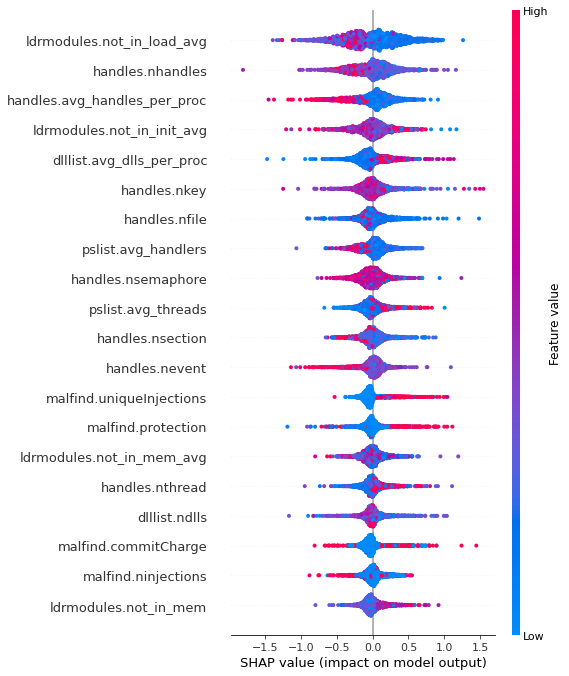

In [ ]:
explainer = shap.Explainer(modelRandomForest.predict, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, plot_type="dot")